# Activation plot

Tracking activation in 2025/26

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime

import ocha_stratus as stratus
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from src.datasources import grdc, abn
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [3]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [4]:
def date_to_season(date):
    if date.month < 6:
        return date.year - 1
    else:
        return date.year

In [5]:
def set_flood_phase(date):
    if date.month >= 6 and date.month <= 9:
        return "l"
    else:
        return "g"

In [6]:
df_grdc["flood_type"] = df_grdc["time"].apply(set_flood_phase)

In [7]:
df_grdc = df_grdc.rename(columns={"time": "date"})

In [8]:
df_grdc["level"] = calculate_stage(df_grdc["runoff_mean"])

In [9]:
df_grdc = df_grdc.dropna(subset="level")
df_grdc["source"] = "grdc"

In [10]:
df_monitoring_2024 = abn.load_current_monitoring()

In [11]:
df_monitoring_2024 = df_monitoring_2024.dropna(subset="level")

In [12]:
df_monitoring_2024["source"] = "abn"

In [13]:
READINESS_THRESH = 592
ACTION_THRESH = 604

In [14]:
df_historical = pd.concat([df_grdc, df_monitoring_2024])

In [15]:
df_historical

,date,runoff_mean,flood_type,level,source
0,1929-01-01,1691.160034,g,568.764994,grdc
5,1929-01-06,1691.160034,g,568.764994,grdc
6,1929-01-07,1704.810059,g,570.806215,grdc
7,1929-01-08,1704.810059,g,570.806215,grdc
8,1929-01-09,1725.270020,g,573.850815,grdc
...,...,...,...,...,...
84,2025-01-19,NaN,NaN,632.000000,abn
85,2025-01-20,NaN,NaN,634.000000,abn
86,2025-01-21,NaN,NaN,635.000000,abn
87,2025-01-22,NaN,NaN,636.000000,abn


In [16]:
def set_plot_date(row):
    try:
        if row["date"].year == row["season"]:
            return datetime(1900, row["date"].month, row["date"].day)
        else:
            return datetime(1901, row["date"].month, row["date"].day)

    except Exception as e:
        print(e)
        print(row["date"])

In [17]:
df_historical["season"] = df_historical["date"].apply(date_to_season)
df_historical["plot_date"] = df_historical.apply(set_plot_date, axis=1)
df_historical["flood_type"] = df_historical["date"].apply(set_flood_phase)

day is out of range for month
1932-02-29 00:00:00
day is out of range for month
1936-02-29 00:00:00
day is out of range for month
1944-02-29 00:00:00
day is out of range for month
1948-02-29 00:00:00
day is out of range for month
1952-02-29 00:00:00
day is out of range for month
1956-02-29 00:00:00
day is out of range for month
1960-02-29 00:00:00
day is out of range for month
1964-02-29 00:00:00
day is out of range for month
1968-02-29 00:00:00
day is out of range for month
1972-02-29 00:00:00
day is out of range for month
1976-02-29 00:00:00
day is out of range for month
1980-02-29 00:00:00
day is out of range for month
1984-02-29 00:00:00
day is out of range for month
1988-02-29 00:00:00
day is out of range for month
1992-02-29 00:00:00
day is out of range for month
1996-02-29 00:00:00
day is out of range for month
2000-02-29 00:00:00
day is out of range for month
2004-02-29 00:00:00
day is out of range for month
2008-02-29 00:00:00
day is out of range for month
2012-02-29 00:00:00


In [18]:
df_historical = df_historical.sort_values(
    by="source", ascending=False, key=lambda s: s.eq("abn")
)

# Drop duplicates, keeping the first occurrence (which will be "abn" if present)
df_historical = df_historical.drop_duplicates(subset="date", keep="first")

In [19]:
df_historical = df_historical.sort_values("date")

In [20]:
df_monitoring_2025 = abn.load_current_monitoring(year=2025)

In [21]:
df_monitoring_2025

,date,level
0,2025-11-01,534.5
1,2025-11-02,537.5
2,2025-11-03,538.0
3,2025-11-04,538.0
4,2025-11-05,539.0
...,...,...
69,2026-01-09,602.0
70,2026-01-10,602.0
71,2026-01-11,602.0
72,2026-01-12,602.0


In [22]:
df_combined = pd.concat([df_historical, df_monitoring_2025], ignore_index=True)

In [23]:
df_combined["season"] = df_combined["date"].apply(date_to_season)
df_combined["plot_date"] = df_combined.apply(set_plot_date, axis=1)
df_combined["flood_type"] = df_combined["date"].apply(set_flood_phase)

day is out of range for month
1932-02-29 00:00:00
day is out of range for month
1936-02-29 00:00:00
day is out of range for month
1944-02-29 00:00:00
day is out of range for month
1948-02-29 00:00:00
day is out of range for month
1952-02-29 00:00:00
day is out of range for month
1956-02-29 00:00:00
day is out of range for month
1960-02-29 00:00:00
day is out of range for month
1964-02-29 00:00:00
day is out of range for month
1968-02-29 00:00:00
day is out of range for month
1972-02-29 00:00:00
day is out of range for month
1976-02-29 00:00:00
day is out of range for month
1980-02-29 00:00:00
day is out of range for month
1984-02-29 00:00:00
day is out of range for month
1988-02-29 00:00:00
day is out of range for month
1992-02-29 00:00:00
day is out of range for month
1996-02-29 00:00:00
day is out of range for month
2000-02-29 00:00:00
day is out of range for month
2004-02-29 00:00:00
day is out of range for month
2008-02-29 00:00:00
day is out of range for month
2012-02-29 00:00:00


In [24]:
gui_df = df_combined[df_combined["flood_type"] == "g"]

In [25]:
gui_df.loc[
    gui_df[gui_df["level"] >= READINESS_THRESH]
    .groupby("season")["date"]
    .idxmin()
]

,date,runoff_mean,flood_type,level,source,season,plot_date
17,1929-01-31,1868.530029,g,594.689912,grdc,1928,1901-01-31
293,1930-01-18,1861.709961,g,593.716045,grdc,1929,1901-01-18
593,1931-01-15,1854.880005,g,592.739005,grdc,1930,1901-01-15
4787,1951-01-28,1855.410034,g,592.814890,grdc,1950,1901-01-28
5170,1952-02-15,1855.410034,g,592.814890,grdc,1951,1901-02-15
5504,1953-01-14,1859.810059,g,593.444437,grdc,1952,1901-01-14
5858,1954-01-03,1859.810059,g,593.444437,grdc,1953,1901-01-03
6223,1955-01-03,1851.890015,g,592.310724,grdc,1954,1901-01-03
6577,1955-12-23,1851.890015,g,592.310724,grdc,1955,1900-12-23
7329,1958-01-13,1851.890015,g,592.310724,grdc,1957,1901-01-13


In [26]:
def custom_date_formatter(x, pos):
    date = mdates.num2date(x)  # Convert numeric value to date
    month_abbr = date.strftime(
        "%b"
    )  # Get abbreviated month name (e.g., "Jan", "Feb")
    day = date.day  # Get day of the month
    translated_month = FRENCH_MONTHS.get(
        month_abbr, month_abbr
    )  # Translate month
    return f"{day} {translated_month}"  # Format as "Translated Month Day"

Text(0.5, 1.0, 'Fleuve Niger à Niamey\nCrues guinéennes (depuis 2000)')

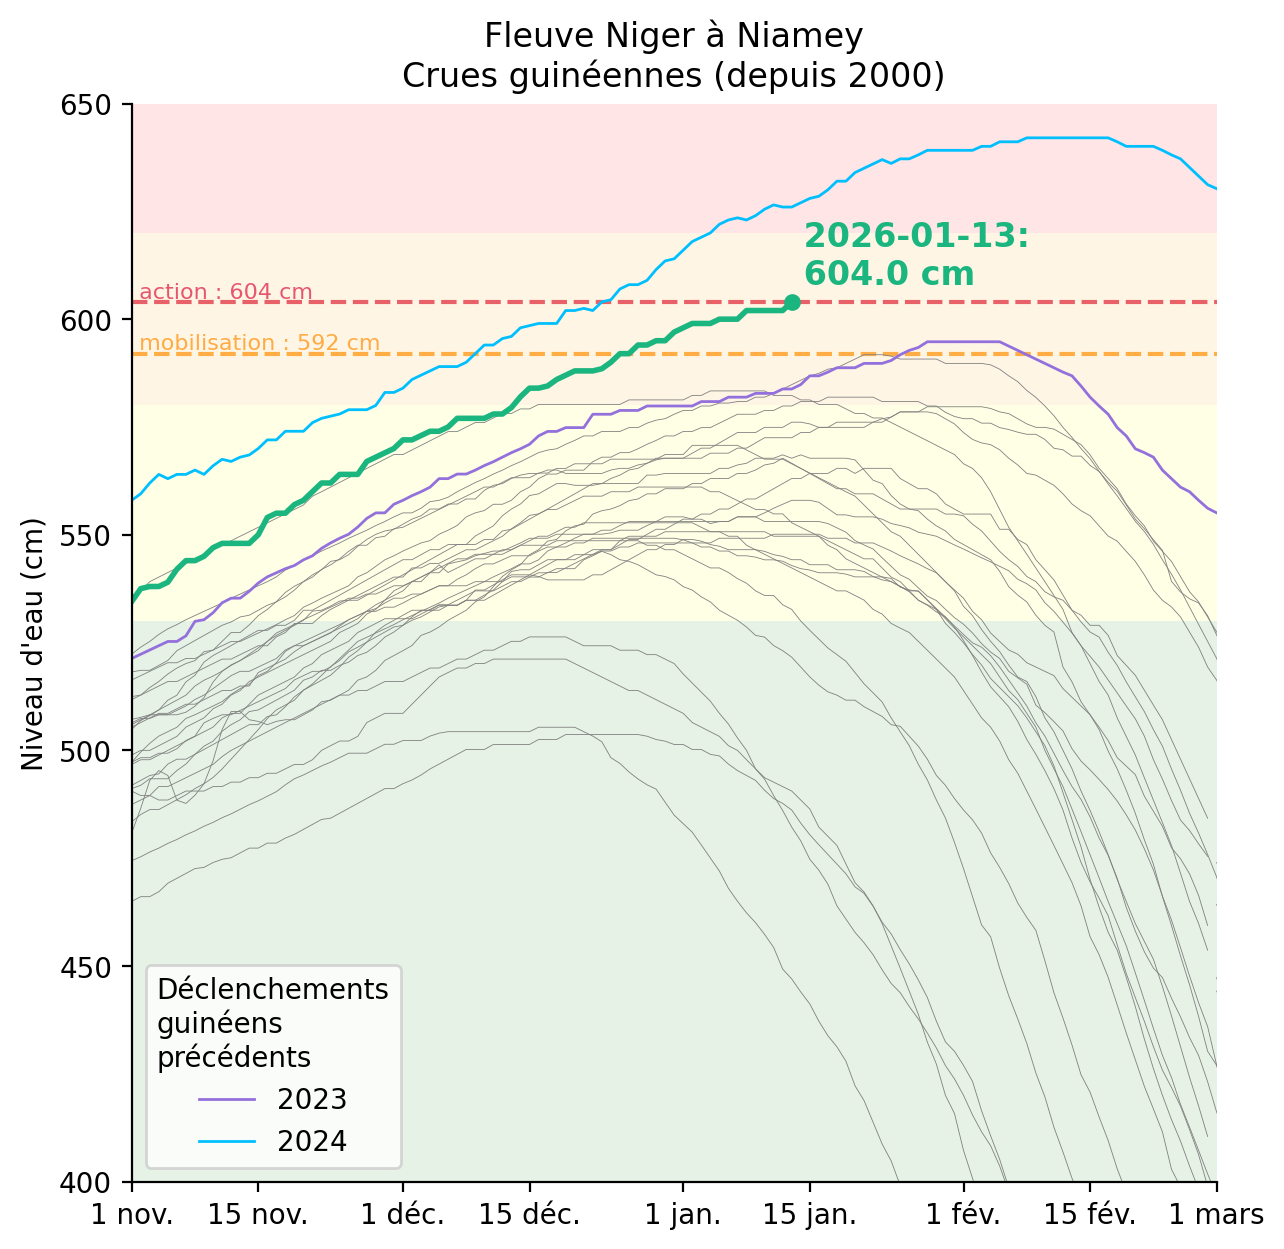

In [27]:
min_year = 2000

fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

seasonyear_colors = {
    2022: "mediumpurple",
    2024: "deepskyblue",
}

for seasonyear in gui_df["season"].unique():
    if seasonyear < min_year:
        continue
    dff = (
        gui_df[gui_df["season"] == seasonyear].copy().dropna(subset=["level"])
    )
    if seasonyear == 2025:
        color = CHD_GREEN
        label = None
        width = 2
    elif seasonyear in seasonyear_colors:
        color = seasonyear_colors.get(seasonyear)
        label = dff[dff["level"] >= READINESS_THRESH]["date"].min().year
        width = 1
    else:
        color = "grey"
        label = None
        width = 0.3
    ax.plot(
        dff["plot_date"],
        dff["level"],
        color=color,
        label=label,
        linewidth=width,
    )

latest_row = gui_df.loc[gui_df["date"].idxmax()]
ax.annotate(
    f' {latest_row["date"].date()}:\n {latest_row["level"]} cm',
    (latest_row["plot_date"], latest_row["level"] + 4),
    color=CHD_GREEN,
    fontsize=12,
    fontweight="bold",
)
ax.plot(
    latest_row["plot_date"],
    latest_row["level"],
    color=CHD_GREEN,
    marker=".",
    markersize=10,
)

ax.legend(title="Déclenchements\nguinéens\nprécédents", loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Niveau d'eau (cm)")
ax.set_xlim(left=datetime(1900, 11, 1), right=datetime(1901, 3, 1))
ax.set_ylim(bottom=400, top=650)

ax.axhspan(0, 530, facecolor="green", alpha=0.1)
ax.axhspan(530, 580, facecolor="yellow", alpha=0.1)
ax.axhspan(580, 620, facecolor="orange", alpha=0.1)
ax.axhspan(620, 700, facecolor="red", alpha=0.1)

alpha = 0.7
for thresh, color, label in [
    (ACTION_THRESH, "crimson", "action"),
    (READINESS_THRESH, "darkorange", "mobilisation"),
]:
    ax.axhline(thresh, color=color, linestyle="--", zorder=-1, alpha=alpha)
    ax.annotate(
        f" {label} : {thresh} cm",
        (datetime(1900, 11, 1), thresh),
        ha="left",
        va="bottom",
        color=color,
        fontsize=8,
        alpha=alpha,
    )

# French dates formatting
ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_date_formatter))

ax.set_title(f"Fleuve Niger à Niamey\nCrues guinéennes (depuis {min_year})")

In [28]:
gui_df[gui_df["season"] >= min_year].groupby("season")[
    "level"
].max().reset_index()

,season,level
0,2000,550.699122
1,2001,552.775458
2,2002,521.164687
3,2003,583.358287
4,2004,526.308627
5,2005,548.614109
6,2006,561.061823
7,2007,570.735013
8,2008,568.531189
9,2009,567.751108


In [29]:
gui_df_recent = gui_df[(gui_df["season"] >= 2000) & (gui_df["season"] < 2025)]

In [30]:
df_recent_peaks = gui_df_recent.loc[
    gui_df_recent.groupby("season")["level"].idxmax()
]

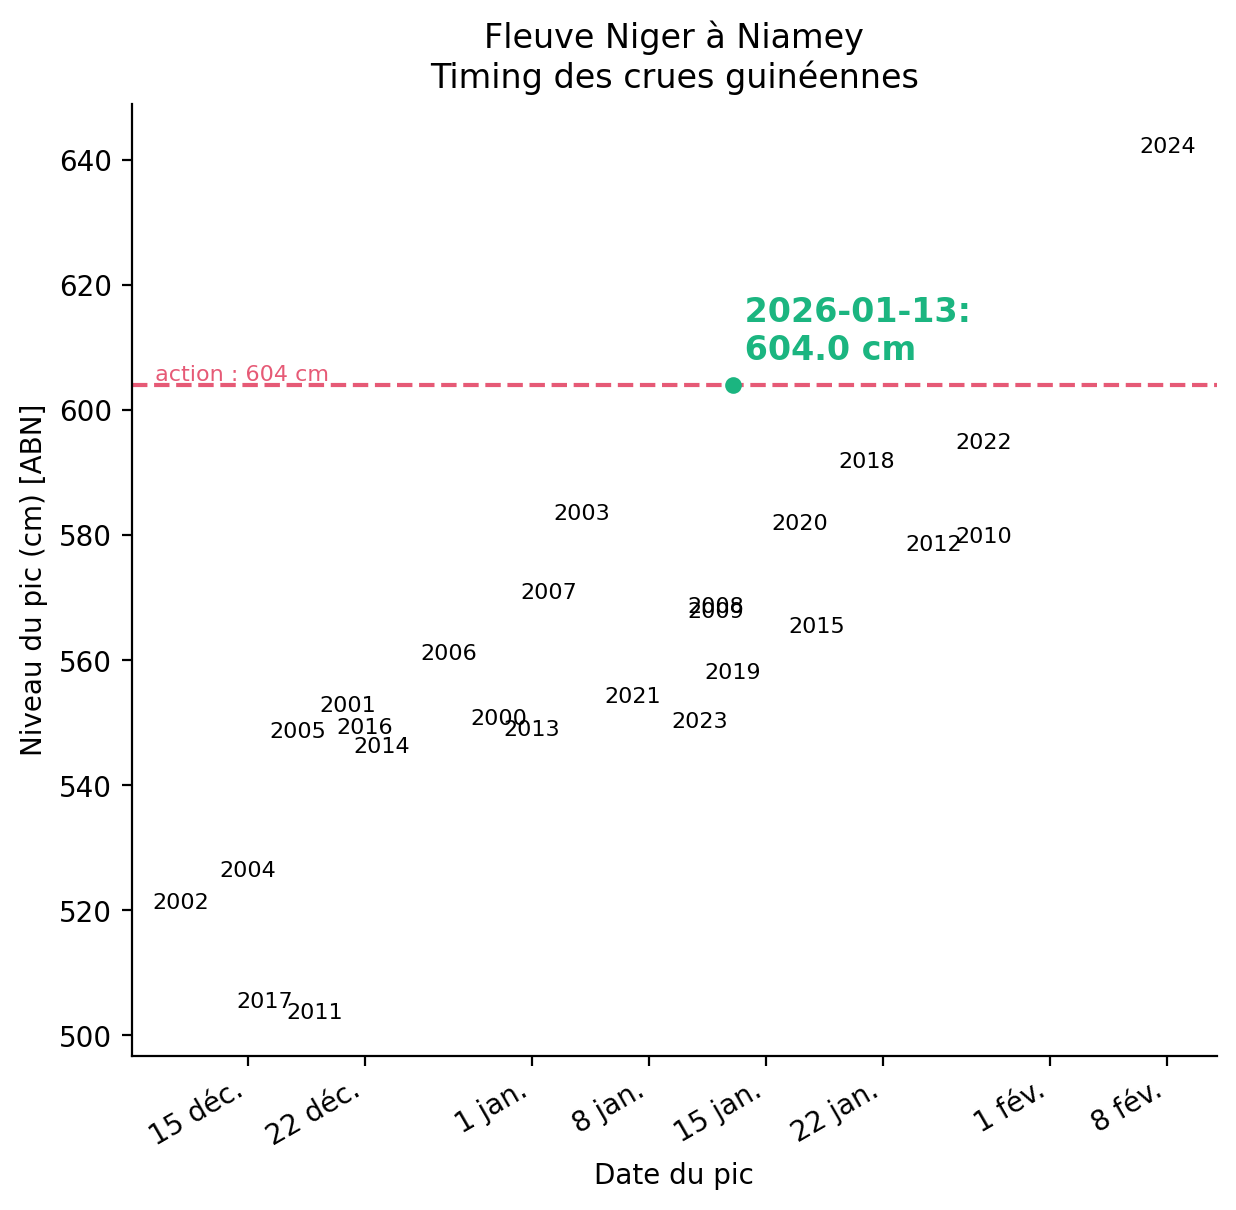

In [31]:
fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

df_recent_peaks.plot(
    x="plot_date", y="level", linewidth=0, ax=ax, legend=False
)


[
    ax.annotate(
        row["season"],
        row[["plot_date", "level"]],
        ha="center",
        va="center",
        fontsize=8,
    )
    for _, row in df_recent_peaks.iterrows()
]

alpha = 0.7
for thresh, color, label in [
    (ACTION_THRESH, "crimson", "action"),
    # (READINESS_THRESH, "darkorange", "mobilisation"),
]:
    ax.axhline(thresh, color=color, linestyle="--", zorder=-1, alpha=alpha)
    ax.annotate(
        f" {label} : {thresh} cm",
        (datetime(1900, 12, 9), thresh),
        ha="left",
        va="bottom",
        color=color,
        fontsize=8,
        alpha=alpha,
    )

latest_row = gui_df.loc[gui_df["date"].idxmax()]
ax.annotate(
    f' {latest_row["date"].date()}:\n {latest_row["level"]} cm',
    (latest_row["plot_date"], latest_row["level"] + 4),
    color=CHD_GREEN,
    fontsize=12,
    fontweight="bold",
)
ax.plot(
    latest_row["plot_date"],
    latest_row["level"],
    color=CHD_GREEN,
    marker=".",
    markersize=10,
)


ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_date_formatter))

ax.set_ylabel("Niveau du pic (cm) [ABN]")
ax.set_xlabel("Date du pic")
ax.set_title("Fleuve Niger à Niamey\nTiming des crues guinéennes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [32]:
drop_years = [1984, 1936]
gui_df_recent_long = gui_df[
    (gui_df["season"] >= 1900)
    & (gui_df["season"] < 2025)
    & ~gui_df["season"].isin(drop_years)
]

In [106]:
df_recent_peaks_long = gui_df_recent_long.loc[
    gui_df_recent_long.groupby("season")["level"].idxmax()
]

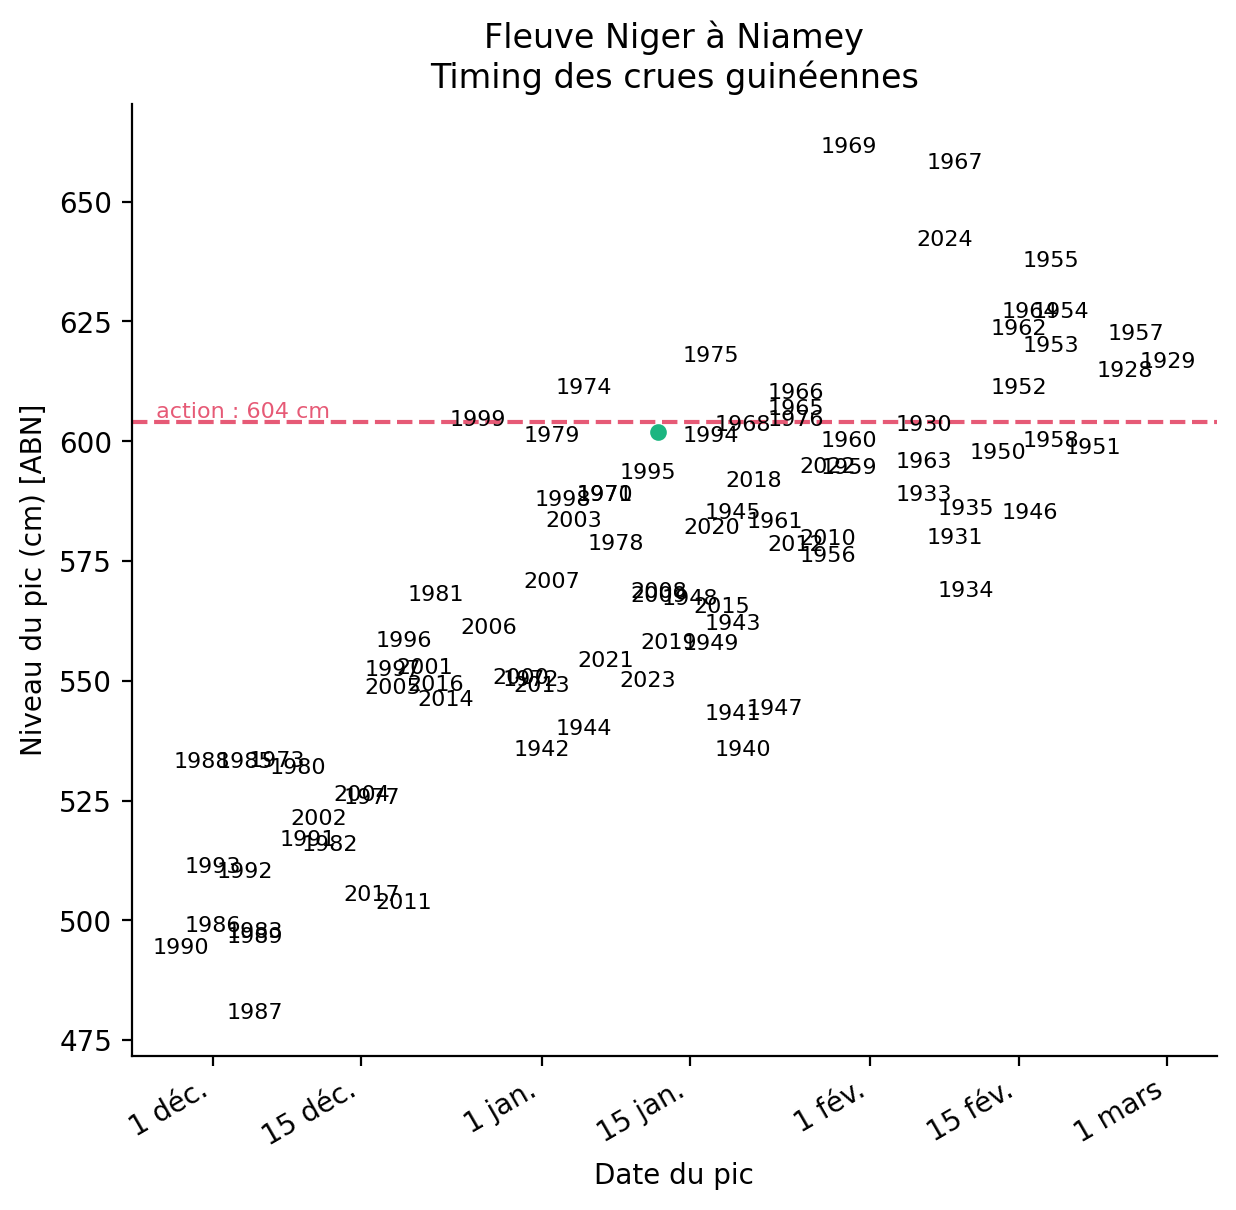

In [111]:
fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

df_recent_peaks_long.plot(
    x="plot_date", y="level", linewidth=0, ax=ax, legend=False
)


[
    ax.annotate(
        row["season"],
        row[["plot_date", "level"]],
        ha="center",
        va="center",
        fontsize=8,
    )
    for _, row in df_recent_peaks_long.iterrows()
]

alpha = 0.7
for thresh, color, label in [
    (ACTION_THRESH, "crimson", "action"),
    # (READINESS_THRESH, "darkorange", "mobilisation"),
]:
    ax.axhline(thresh, color=color, linestyle="--", zorder=-1, alpha=alpha)
    ax.annotate(
        f" {label} : {thresh} cm",
        (datetime(1900, 11, 25), thresh),
        ha="left",
        va="bottom",
        color=color,
        fontsize=8,
        alpha=alpha,
    )

latest_row = gui_df.loc[gui_df["date"].idxmax()]
# ax.annotate(
#     f' {latest_row["date"].date()}:\n {latest_row["level"]} cm',
#     (latest_row["plot_date"], latest_row["level"] + 4),
#     color=CHD_GREEN,
#     fontsize=12,
#     fontweight="bold",
# )
ax.plot(
    latest_row["plot_date"],
    latest_row["level"],
    color=CHD_GREEN,
    marker=".",
    markersize=10,
)


ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_date_formatter))

ax.set_ylabel("Niveau du pic (cm) [ABN]")
ax.set_xlabel("Date du pic")
ax.set_title("Fleuve Niger à Niamey\nTiming des crues guinéennes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [37]:
gui_df[(gui_df["season"] == 2024) & (gui_df["level"] >= 604)]

,date,runoff_mean,flood_type,level,source,season,plot_date
31738,2024-12-23,NaN,g,604.000000,abn,2024,1900-12-23
31739,2024-12-24,NaN,g,604.500000,abn,2024,1900-12-24
31740,2024-12-25,NaN,g,607.000000,abn,2024,1900-12-25
31741,2024-12-26,NaN,g,608.000000,abn,2024,1900-12-26
31742,2024-12-27,NaN,g,608.000000,abn,2024,1900-12-27
...,...,...,...,...,...,...,...
31819,2025-03-14,2010.0,g,614.510323,grdc,2024,1901-03-14
31820,2025-03-15,1995.0,g,612.442048,grdc,2024,1901-03-15
31821,2025-03-16,1974.0,g,609.533553,grdc,2024,1901-03-16
31822,2025-03-17,1960.0,g,607.586085,grdc,2024,1901-03-17


In [39]:
gui_df[(gui_df["season"] == 2024) & (gui_df["level"] >= 620)]

,date,runoff_mean,flood_type,level,source,season,plot_date
31750,2025-01-04,NaN,g,620.000000,abn,2024,1901-01-04
31751,2025-01-05,NaN,g,622.000000,abn,2024,1901-01-05
31752,2025-01-06,NaN,g,623.000000,abn,2024,1901-01-06
31753,2025-01-07,NaN,g,623.500000,abn,2024,1901-01-07
31754,2025-01-08,NaN,g,623.000000,abn,2024,1901-01-08
...,...,...,...,...,...,...,...
31810,2025-03-05,2097.0,g,626.359233,grdc,2024,1901-03-05
31811,2025-03-06,2089.0,g,625.279918,grdc,2024,1901-03-06
31812,2025-03-07,2082.0,g,624.333846,grdc,2024,1901-03-07
31813,2025-03-08,2060.0,g,621.350225,grdc,2024,1901-03-08


In [40]:
gui_df[(gui_df["season"] == 2024) & (gui_df["level"] >= 640)]

,date,runoff_mean,flood_type,level,source,season,plot_date
31780,2025-02-03,2200.0,g,640.078230,grdc,2024,1901-02-03
31781,2025-02-04,2200.0,g,640.078230,grdc,2024,1901-02-04
31782,2025-02-05,2208.0,g,641.130393,grdc,2024,1901-02-05
31783,2025-02-06,2208.0,g,641.130393,grdc,2024,1901-02-06
31784,2025-02-07,2208.0,g,641.130393,grdc,2024,1901-02-07
31785,2025-02-08,2215.0,g,642.049494,grdc,2024,1901-02-08
31786,2025-02-09,2215.0,g,642.049494,grdc,2024,1901-02-09
31787,2025-02-10,2215.0,g,642.049494,grdc,2024,1901-02-10
31788,2025-02-11,2215.0,g,642.049494,grdc,2024,1901-02-11
31789,2025-02-12,2215.0,g,642.049494,grdc,2024,1901-02-12
